In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import urllib.request

# DATASET LOADING LOGIC

In [49]:
# 1. Store Column Names in a List 
# column_names = [
#     "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
#     "gill-attachment", "gill-spacing", "gill-size", "gill-color",
#     "stalk-shape", "stalk-root", "stalk-surface-above-ring",
#     "stalk-surface-below-ring", "stalk-color-above-ring",
#     "stalk-color-below-ring", "veil-type", "veil-color", "ring-number",
#     "ring-type", "spore-print-color", "population", "habitat"
# ]

# 2. Read the .data file (CSV)
# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
# df = pd.read_csv(url, header=None, names=column_names, na_values='?')

## OR ( THIS ABOVE IS ALSO CORRECT)

In [50]:
# Download files
urllib.request.urlretrieve("https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data", "mushroom.data")
urllib.request.urlretrieve("https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.names", "mushroom.names")


('mushroom.names', <http.client.HTTPMessage at 0x248d170f980>)

In [51]:
# 1. READ .NAMES FILE to get column list
cols = ['class'] 
with open("mushroom.names", 'r') as f:
    for line in f:
      
        if len(cols) < 23 and line.strip() and line.strip()[0].isdigit():
            name = line.split(':')[0].split('.')[-1].strip()
            cols.append(name)

# 2. READ .DATA FILE to get data list
data = []
with open("mushroom.data", 'r') as f:
    for line in f:
        data.append(line.strip().split(','))

# 3. MERGE LIST WITH DATAFRAME
df = pd.DataFrame(data, columns=cols)
df.head()

,class,Title,Sources,Past Usage,Concept Acquisition Through Representational,,Trading off Simplicity,In the following references a set of rules (given below) were,52% accuracy,41% accuracy,...,Number of Instances,Number of Attributes,Attribute Information,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


# TASK 1: Exploratory Data Analysis (EDA)

In [52]:

df.head()

,class,Title,Sources,Past Usage,Concept Acquisition Through Representational,,Trading off Simplicity,In the following references a set of rules (given below) were,52% accuracy,41% accuracy,...,Number of Instances,Number of Attributes,Attribute Information,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [53]:
df.shape


(8124, 23)

In [54]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                                                         Non-Null Count  Dtype
---  ------                                                         --------------  -----
 0   class                                                          8124 non-null   str  
 1   Title                                                          8124 non-null   str  
 2   Sources                                                        8124 non-null   str  
 3   Past Usage                                                     8124 non-null   str  
 4   Concept Acquisition Through Representational                   8124 non-null   str  
 5                                                                  8124 non-null   str  
 6   Trading off Simplicity                                         8124 non-null   str  
 7   In the following references a set of rules (given below) were  8124 non-null   str  
 8  

In [55]:
df.describe()

,class,Title,Sources,Past Usage,Concept Acquisition Through Representational,,Trading off Simplicity,In the following references a set of rules (given below) were,52% accuracy,41% accuracy,...,Number of Instances,Number of Attributes,Attribute Information,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


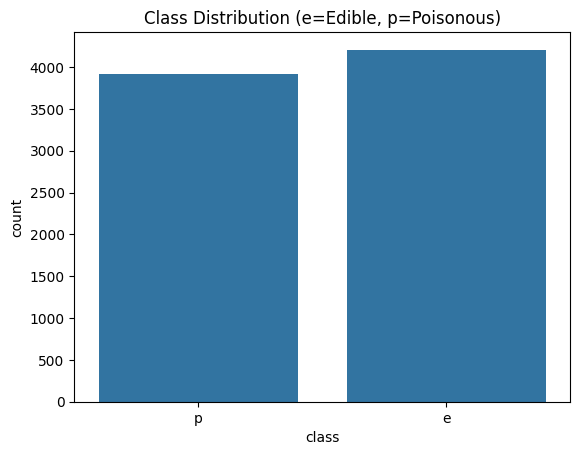

In [56]:
# 3. Visualization of the data
sns.countplot(x='class', data=df)
plt.title('Class Distribution (e=Edible, p=Poisonous)')
plt.show()

# TASK 2: Data Cleaning & Transformation

In [57]:
# 1. Handling Missing Values
# We used na_values='?' during loading, so we just drop them now.
df.dropna(inplace=True)

In [58]:
# 2. Outlier Detection
# Not required for categorical text data.

In [59]:
# 3. Feature Transformation (Encoding)
# Decision Trees need numbers, not text. We convert text to numbers.
le = LabelEncoder()
df = df.apply(le.fit_transform)

# TASK 3: Decision Tree Model Building

In [60]:
# 1. Split the dataset
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 2. Train Decision Tree Classifier with Pre-Pruning
# SOLUTION: Added max_depth and min_samples_leaf to prevent overfitting
model = DecisionTreeClassifier(
    criterion='entropy',       
    max_depth=4,              
    min_samples_leaf=5,       
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

# TASK 4: Model Evaluation

In [62]:
# 1. Predict the test data
y_pred = model.predict(X_test)

In [63]:
# 2. Check for Overfitting (Compare Train vs Test Accuracy)
train_acc = model.score(X_train, y_train)
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")

# If Training Accuracy is much higher than Testing (e.g., 1.0 vs 0.85), it is overfitted.
# Ideally, they should be close.

print(f"\nFinal Test Accuracy Score: {test_acc:.4f}")

Training Accuracy: 0.9592
Testing Accuracy:  0.9489

Final Test Accuracy Score: 0.9489


In [64]:
# 3. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       843
           1       0.92      0.98      0.95       782

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625



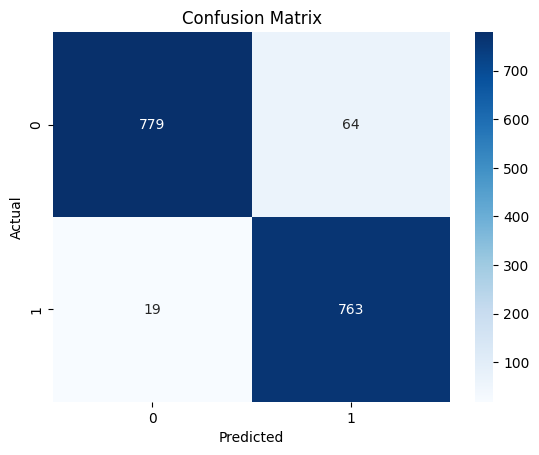

In [65]:
# 4. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


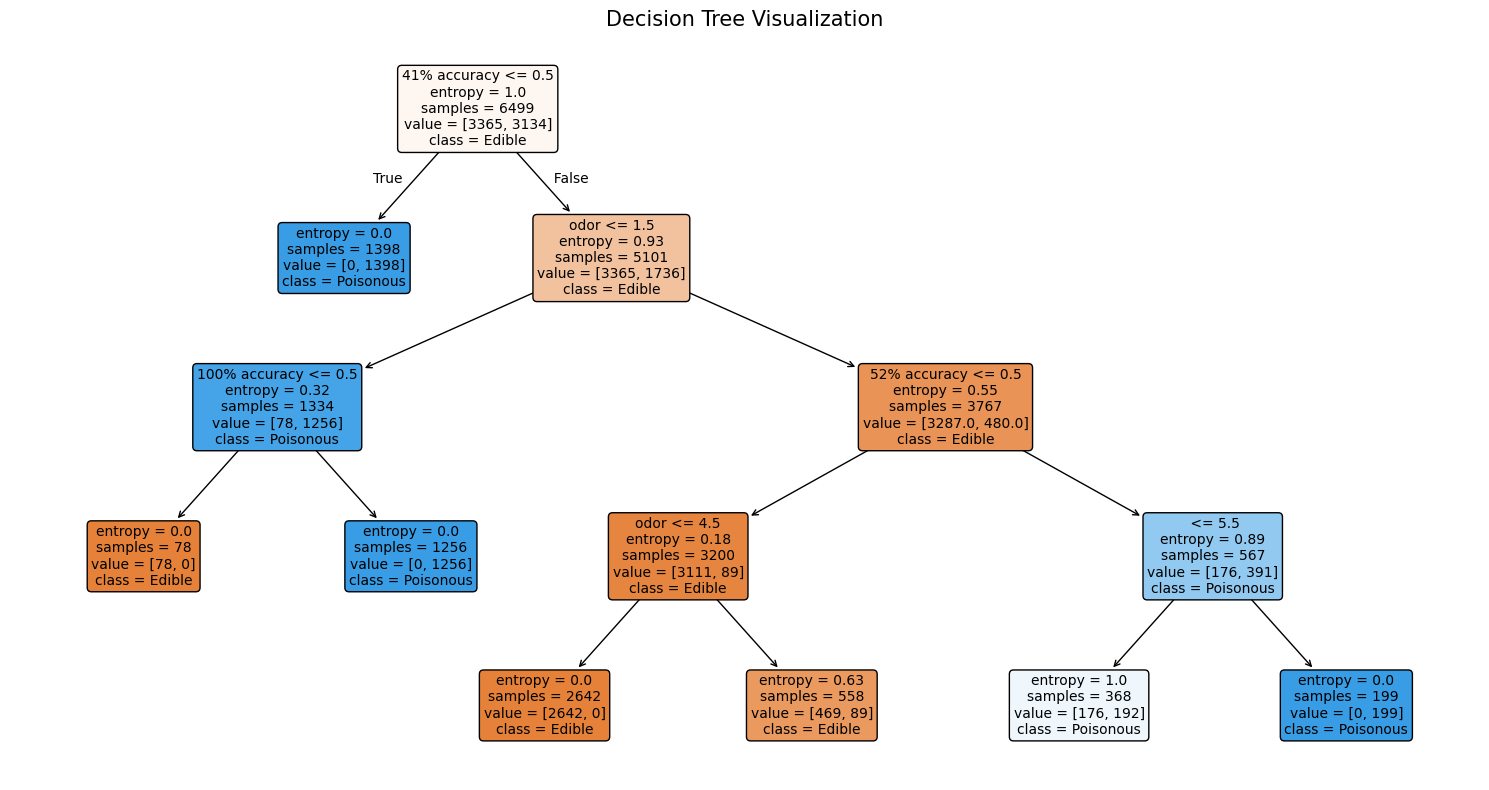

In [66]:
# 5. Visualize the Decision Tree 
plt.figure(figsize=(15, 8))  

plot_tree(model, 
          filled=True, 
          feature_names=X.columns, 
          class_names=['Edible', 'Poisonous'],
          rounded=True,      
          fontsize=10,      
          precision=2,       
          proportion=False   
)

plt.title("Decision Tree Visualization", fontsize=15)
plt.tight_layout()  
plt.show()

# TASK 5: Hyperparameter Tuning (Pre-Pruning)

In [67]:
# Define a list of parameters to test
tuning_params = [
    {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1},
    {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2},
    {'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4}
]

print("\n--- Hyperparameter Tuning Results ---")
best_acc = 0
best_params = {}


--- Hyperparameter Tuning Results ---


In [68]:
# Train multiple models
for p in tuning_params:
    clf = DecisionTreeClassifier(
        max_depth=p['max_depth'],
        min_samples_split=p['min_samples_split'],
        min_samples_leaf=p['min_samples_leaf'],
        random_state=42
    )
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    
    print(f"Params: {p} -> Accuracy: {acc:.4f}")
       
    if acc > best_acc:
        best_acc = acc
        best_params = p

print(f"\nBest Parameter Combination: {best_params}")
print(f"Best Accuracy: {best_acc:.4f}")

Params: {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1} -> Accuracy: 0.9520
Params: {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2} -> Accuracy: 0.9766
Params: {'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4} -> Accuracy: 1.0000

Best Parameter Combination: {'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4}
Best Accuracy: 1.0000
